In [1]:
!pip install --upgrade scikit-learn imblearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.5/13.5 MB 101.3 MB/s eta 0:00:0000:010:01
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.2.2
    Uninstalling scikit-learn-1.2.2:
      Successfully uninstalled scikit-learn-1.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
category-encoders 2.7.0 requires scikit-learn<1.6.0,>=1.0.0, but you have scikit-learn 1.6.1 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.


In [2]:
import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset,DataLoader,Sampler,BatchSampler
# from torchvision.transforms import v2
import math
from torchvision import transforms as T
from torchvision.transforms import InterpolationMode
import torch.nn.functional as F
import torchvision.transforms.functional as TVF
from torchvision import models
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report,confusion_matrix , ConfusionMatrixDisplay
from torch.utils.data.sampler import WeightedRandomSampler
from collections import Counter
import seaborn as sns
import os
import random
import cv2
from tqdm.notebook import tqdm
import random
from PIL import Image
from sklearn.metrics import f1_score,accuracy_score
import subprocess
from IPython.display import FileLink, display
import copy
from sklearn.decomposition import PCA
import kornia.filters as KF
from umap import UMAP  

2025-08-02 20:23:11.180675: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1754166191.380311      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1754166191.439215      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
def download_file(path, download_file_name):
    os.chdir('/kaggle/working/')
    zip_name = f"/kaggle/working/{download_file_name}.zip"
    command = f"zip {zip_name} {path} -r"
    result = subprocess.run(command, shell=True, capture_output=True, text=True)
    if result.returncode != 0:
        print("Unable to run zip command!")
        print(result.stderr)
        return
    display(FileLink(f'{download_file_name}.zip'))

In [4]:
img_path="/kaggle/input/infrared-solar-modules/2020-02-14_InfraredSolarModules/InfraredSolarModules"
meta_data_path="/kaggle/input/infrared-solar-modules/2020-02-14_InfraredSolarModules/InfraredSolarModules/module_metadata.json"
class_mappings={"No-Anomaly":0,"Cell":1,
                "Cell-Multi":2,"Cracking":3,"Hot-Spot":4,
                "Hot-Spot-Multi":5,"Shadowing":6,"Diode":7,
                "Diode-Multi":8,"Vegetation":9,"Soiling":10,
                "Offline-Module":11
               }
class_keys=["No-Anomaly","Cell","Cell-Multi","Cracking","Hot-Spot","Hot-Spot-Multi","Shadowing","Diode",
                "Diode-Multi","Vegetation","Soiling","Offline-Module"]
anomaly_keys=["No-Anomaly","Anomaly"]

In [5]:
with open(meta_data_path, 'r') as f:
    metadata = json.load(f)

In [6]:
def create_df(combine_similar=False):
    if(combine_similar):
        class_mappings={
            "No-Anomaly":0,"Cell":1,
            "Cell-Multi":1,"Hot-Spot":2,
            "Hot-Spot-Multi":2,"Shadowing":3,"Diode":4,
            "Diode-Multi":4,
            "Offline-Module":5}
        class_keys=["No-Anomaly","Cell","Hot-Spot","Shadowing","Diode","Offline-Module"]
    dic={"image_path":[],"class":[]}
    for key in metadata:
        if metadata[key]["anomaly_class"] not in class_keys:
            continue
        dic["image_path"]+=[os.path.join(img_path,metadata[key]["image_filepath"])]
        num_class=class_mappings[metadata[key]["anomaly_class"]]
        dic["class"]+=[num_class]
    df=pd.DataFrame(dic)
    return df , class_mappings , class_keys , len(class_keys)

# Helpers

## Drawing

In [7]:
def draw(axes,items,index,titles,with_path=True,steps=1,cmap="jet",vmin=None,vmax=None):
    c=len(titles)
    i=0
    for item in items:
        if(with_path):
            img = Image.open(p)
        else:
            img=item
        im=axes[index].imshow(img,cmap=cmap,vmin=vmin, vmax=vmax)
        axes[index].set_title(titles[i%c])
        plt.colorbar(im, ax=axes[index], fraction=0.046, pad=0.01)
        index+=steps
        i+=1
    return index
def show_samples(sampled):
    classes=sampled["class"].unique()
    fig,axes=plt.subplots(12,5,figsize=(25,96))
    axes=axes.reshape(-1)
    i=0
    for c in classes:
        paths=sampled[sampled["class"]==c]["image_path"].values
        titles=[class_keys[c]]
        i=draw(axes,paths,i,titles)
def visualize_latent_dim(model,x,y,transforms,class_keys):
    fig,ax=plt.subplots(1,2,figsize=(16,8))
    device = "cuda" if torch.cuda.is_available() else "cpu"
    ds=SolarImgDataset(x,y,transforms)
    pca_model=PCA(n_components=5)
    pca_model_2d=PCA(n_components=2)
    reducer = UMAP(n_neighbors=15, min_dist=0.1,n_components=2,random_state=42)
    model.eval()
    dl=DataLoader(
        ds,
        batch_size=128,
        num_workers=4,
        pin_memory=True
    )
    with torch.no_grad():
        Y=[]
        X=[]
        for x,y in tqdm(dl):
            x=x.to(device)
            embs=model(x)
            X+=[embs.to("cpu")]
            Y+=[y]
    X=torch.cat(X,dim=0).numpy()
    Y=torch.cat(Y,dim=0).numpy()
    
    X_pca=pca_model.fit_transform(X)
    X_u=reducer.fit_transform(X_pca)
    X_pca_2d=pca_model_2d.fit_transform(X)
    
    sns.scatterplot(x=X_u[:,0],y=X_u[:,1],hue=Y,ax=ax[0],legend="full",palette="tab20")
    handles0, _ = ax[0].get_legend_handles_labels()
    ax[0].legend(handles0, class_keys)
    ax[0].set_title("pca+umap")
    
    sns.scatterplot(x=X_pca_2d[:,0],y=X_pca_2d[:,1],hue=Y,ax=ax[1],legend="full",palette="tab20")
    handles1, _ = ax[1].get_legend_handles_labels()
    ax[1].legend(handles1, class_keys)
    ax[1].set_title("pca")
    fig.tight_layout()
    model.train()

## Dataset Balancing

In [8]:
def oversampling(X,Y,sampling_strategy):
    # ro_sampler=SMOTE(random_state=42)
    ro_sampler=RandomOverSampler(random_state=42,sampling_strategy=sampling_strategy)
    x_bal,y_bal=ro_sampler.fit_resample(X,Y)
    return x_bal,y_bal

# Datasets

In [9]:
class SolarImgDataset():
    def __init__(self,x,y,transformer):
        super(SolarImgDataset,self).__init__()
        self.imgs=x
        self.classes=y
        self.transform=transformer
    def __len__(self):
        return len(self.classes)
    def __getitem__(self,index):
        t_img=self.imgs[index]
        # print(t_img.shape)
        t_img=self.transform(t_img)
        c=self.classes[index]
        return t_img,c
class DrawImgDataset(Dataset):
    def __init__(self,x,y,train_transformer,test_transformer):
        super(DrawImgDataset,self).__init__()
        self.imgs=x
        self.classes=y
        self.train_transformer=train_transformer
        self.test_transformer=test_transformer
    def __len__(self):
        return len(self.classes)
    def __getitem__(self,index):
        img_PIL=self.imgs[index]
        t_img=self.train_transformer(img_PIL)
        test_img=self.test_transformer(img_PIL)
        
        c=self.classes[index]
        return t_img,test_img,c

# Models

## Contrastive Models

### Samll Encoder

In [10]:
class Encoder(nn.Module):
    def __init__(self, in_ch=1, latent_dim = 128):
        super(Encoder, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch,16,kernel_size=3, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(16),
            nn.Conv2d(16,32,kernel_size=3, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(32),
            nn.Conv2d(32,64,kernel_size=3, stride=1, padding="same"),
            nn.ReLU(inplace=True)
        )
        self.flatten = nn.Flatten()
        self.fc = nn.Sequential(
            nn.Linear(64*12*20, 512),
            nn.Dropout(0.1),
            nn.ReLU(),
            nn.Linear(512,latent_dim),
            nn.Dropout(0.1),
            nn.ReLU(),
        )

    def forward(self, x):
        x=self.conv(x)
        x=self.flatten(x)
        z=self.fc(x)
        return z
        

### VGG16

In [11]:
class VGG16(nn.Module):
    def __init__(self,latent_dim=128):
        super().__init__()
        self.vgg=models.vgg16(weights="DEFAULT")
        self.fc_model=nn.Sequential(
            nn.Linear(1000, latent_dim),
            nn.ReLU(True),
        )
    def forward(self,x):
        x=self.vgg(x)
        z=self.fc_model(x)
        return z

### Big Encoder

In [12]:
class ConvBlock(nn.Module):
    def __init__(self,in_c,out_c,pool=True):
        super().__init__()
        layers=[
            nn.Conv2d(in_c,out_c,kernel_size=(3,3),stride=1,padding=1),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(out_c)
        ]
        if(pool):
            layers+=[nn.MaxPool2d(2,stride=2,padding=0,ceil_mode=True)]
            
        self.conv=nn.Sequential(
            *layers            
        )
    def forward(self,x):
        return self.conv(x)
class BigClassifier(nn.Module):
    def __init__(self,inc=1,latent_dim=128):
        super().__init__()
        self.cnn_model=nn.Sequential(
            ConvBlock(inc,42),
            ConvBlock(42,42),
            ConvBlock(42,50,False),
            ConvBlock(50,72),
            ConvBlock(72,98,False),
            ConvBlock(98,128),
            ConvBlock(128,256),
            ConvBlock(256,512,False)
        )
        self.flatten=nn.Flatten()
        self.fc_model=nn.Sequential(
            nn.Linear(512*2*1, latent_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1)
        )
    def forward(self,x):
        x=self.cnn_model(x)
        x=self.flatten(x)
        z=self.fc_model(x)
        return z

### ResNet

In [13]:
class ResnetModel(nn.Module):
    def __init__(self,latent_dim=128,classification_mode=False):
        super(ResnetModel,self).__init__()
        self.classification_mode=classification_mode
        resnet=models.resnet50(weights="DEFAULT")
        self.model=nn.Sequential(*list(resnet.children())[:-2])
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.flatten=nn.Flatten(1)
        self.projection_head=nn.Sequential(
            nn.Linear(2048, 2048),
            nn.ReLU(inplace=True),
            nn.Linear(2048, latent_dim)
        )
        # self.model=resnet
    def set_classification_mode(self,mode=True):
        self.classification_mode=mode
    def forward(self,x):
        z=self.model(x)
        z=self.avgpool(z)
        z=self.flatten(z)
        if(not self.classification_mode):
            z=self.projection_head(z)
        return z
        # return z

## Classifiers

In [14]:
class BaseClassifier(nn.Module):
    def __init__(self,encoder,classifier,train_encoder):
        super().__init__()
        self.encoder=encoder
        self.classifier=classifier
        self.train_encoder=train_encoder
    def train(self,mode=True):
        self.classifier.train(mode)
        if(self.train_encoder):
            self.encoder.train(mode)
        else:
            self.encoder.eval()
        return self
    def forward(self,x):
        if(self.train_encoder):
            embs=self.encoder(x)
        else:
            with torch.no_grad():
                embs=self.encoder(x)
        return self.classifier(embs)
        
class Classifier(BaseClassifier):
    def __init__(self,encoder,class_count,input_dim=2048,latent_dim=128,train_encoder=False):
        encoder=encoder
        classifier=nn.Sequential(
            nn.Linear(input_dim, input_dim),     
            nn.BatchNorm1d(input_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(input_dim, 12)

        )
        super().__init__(encoder,classifier,train_encoder)
        if(not self.train_encoder):
            for p in self.encoder.parameters():
                p.requires_grad = False


# Losses

In [15]:
class ContrastiveLoss(nn.Module):
    def __init__(self, temperature=0.07, diff_coef=1.0, class_weights=None):
        super().__init__()
        self.temperature = temperature
        self.diff_coef = diff_coef

        self.class_weights = None

    def forward(self, x, y):
        device = x.device
        z = F.normalize(x, dim=1)  # (N, D)
        batch_size = z.size(0)
        logits = torch.matmul(z, z.T) / self.temperature 
        self_mask = torch.eye(batch_size, device=device).bool() 
        logits_for_den = logits.masked_fill(self_mask, float("-inf"))
        logsumexp = torch.logsumexp(logits_for_den, dim=1, keepdim=True)
        log_prob = logits - logsumexp 
        y = y.view(-1, 1)
        eq_mask = torch.eq(y, y.T) 
        pos_mask = eq_mask & (~self_mask
        pos_count = pos_mask.sum(dim=1) 
        valid = pos_count > 0 
        if valid.sum() == 0:
            return torch.tensor(0.0, device=device, requires_grad=True)
        mean_log_prob_pos = (log_prob * pos_mask.float()).sum(dim=1) / pos_count.clamp(min=1).float() 

        loss_per_sample = -mean_log_prob_pos[valid] 

        loss = loss_per_sample.mean()

        return loss * self.diff_coef
        
class FocalCrossEntropy(nn.Module):
    def __init__(self, weights, gamma=2.0,device="cuda"):
        super().__init__()
        self.weights=weights.to(device)
        self.gamma=gamma

    def forward(self, logits, targets):
        log_probs = F.log_softmax(logits, dim=1)
        prob = log_probs.exp()

        targets=targets.view(-1,1)
        log_pt = log_probs.gather(1,targets).squeeze(1)
        pt= prob.gather(1,targets).squeeze(1)
        a=self.weights.gather(0,targets.squeeze(1))
        loss= - a* (((1 - pt)**self.gamma) * log_pt)

        return loss.mean()


# Samplers

In [16]:
class EqualSampler(Sampler):

    def __init__(self, labels, classes_per_batch=12, n_each_class=2, drop_last=True):
        self.labels = np.array(labels)
        self.classes_per_batch = classes_per_batch
        self.n_each_class = n_each_class
        self.drop_last = drop_last

        self.classes = np.unique(self.labels).tolist()

        self.class_indices = {
            c: np.where(self.labels == c)[0].tolist()
            for c in self.classes
        }
        self.chunks_per_class = {
            c: len(idxs) // n_each_class
            for c, idxs in self.class_indices.items()
        }
        total_chunks = sum(self.chunks_per_class.values())
        self.num_batches =math.ceil(total_chunks / classes_per_batch)
    def __iter__(self):
        class_chunks = {}
        class_selected_counter={}
        for c, idxs in self.class_indices.items():
            random.shuffle(idxs)
            chunks = [
                idxs[i : i + self.n_each_class]
                for i in range(0, len(idxs), self.n_each_class)
                if len(idxs[i : i + self.n_each_class]) == self.n_each_class
            ]
            class_chunks[c] = chunks
            class_selected_counter[c]=np.ones(len(chunks))
        classes_available= np.array(self.classes)
        
        for i in range(self.num_batches):
            batch = []
            mask=np.ones(len(classes_available))
            for j in range(self.classes_per_batch):
                valid_indices = np.nonzero(mask)[0]
                c = np.random.choice(valid_indices)
                mask[c]=0
                chunk_probs=(1/class_selected_counter[c])/((1/class_selected_counter[c]).sum())
                selected_chunk_idx = np.random.choice(len(class_chunks[c]),p=chunk_probs)
                selected_chunk=class_chunks[c][selected_chunk_idx]
                class_selected_counter[c][selected_chunk_idx]+=1
                batch.extend(selected_chunk)
            if len(batch) == self.classes_per_batch * self.n_each_class or not self.drop_last:
                yield batch

    def __len__(self):
        return self.num_batches


# Augmentations

In [17]:
class RandomContrast:
    def __init__(self, lower=0.5, upper=1.5):
        self.lower = lower
        self.upper = upper
    def __call__(self, img):
        factor = random.uniform(self.lower, self.upper)
        return TVF.adjust_contrast(img, factor)
class AddGaussianNoise:
    def __init__(self, mean=0, std=0.02,bounds=(0.,1.)):
        self.mean=mean
        self.std=std
        self.bounds=bounds
    def __call__(self,img):
        return (img+torch.normal(mean=self.mean, std=self.std, size=img.shape)).clamp(*self.bounds)

# Training Functions

In [18]:
def predict(model,x):
    logits= model(x)
    preds=logits.argmax(dim=1)
    pred_labels=preds.tolist()
    return pred_labels

def evaluate(model,dataloader,device,criterion,with_acc=False):
    model.eval()
    total_loss, total_correct = 0.0, 0
    pred_labels=[]
    true_labels=[]
    with torch.no_grad():
        for imgs, labels in dataloader:
            imgs, labels = imgs.to(device), labels.to(device)
                
            logits= model(imgs)
            loss= criterion(logits, labels)

            total_loss+=loss.item()*imgs.size(0)
            # total_correct+=(logits.argmax(dim=1)==labels).sum().item()

            preds=logits.argmax(dim=1)
            true_labels+=labels.tolist()
            pred_labels+=preds.tolist()

        avg_loss = total_loss/len(dataloader.dataset)
        acc=0
        if(with_acc==True):

            acc=accuracy_score(true_labels,pred_labels)
            print(f"loss: {avg_loss:.4f}, acc: {acc:.4%}")
        else:
             print(f"loss: {avg_loss:.4f}")
        # f1=f1_score(true_labels,pred_labels)
        
        return acc,avg_loss
def trainer(
    model,
    dataloader,
    test_dataloader,
    optimizer,
    criterion,
    num_epochs = 30,
    device = "cuda" if torch.cuda.is_available() else "cpu",
    stop_at_acc=1,
    with_acc=False,
    return_best=True
):
    model.to(device)

    min_test_loss=float("inf")
    best_ep=0
    best_model_params = copy.deepcopy(model.state_dict())
    for epoch in tqdm(range(1, num_epochs + 1)):
        model.train()
        total_loss, total_correct=0.0,0
        pred_labels=[]
        true_labels=[]
        for imgs,labels in tqdm(dataloader):
            imgs,labels= imgs.to(device), labels.to(device)
            # print(imgs.shape)
            optimizer.zero_grad()

            logits= model(imgs)
            loss= criterion(logits, labels)

            loss.backward()
            optimizer.step()

            total_loss+=loss.item()*imgs.size(0)
            # total_correct+=(logits.argmax(dim=1)==labels).sum().item()

            preds=logits.argmax(dim=1)
            true_labels+=labels.tolist()
            pred_labels+=preds.tolist()
        
        avg_loss=total_loss/len(dataloader.dataset)
        train_report=f"Epoch {epoch:02d} — loss: {avg_loss:.4f}"
        if(with_acc):
            acc=accuracy_score(true_labels,pred_labels)
            train_report+=f" — acc: {acc:.4%}"
        # acc= total_correct/len(dataloader.dataset)
        
        # f1=f1_score(true_labels,pred_labels)
        print(train_report)

        test_acc,test_loss=evaluate(
            model,
            test_dataloader,
            device,
            criterion,
            with_acc=with_acc
        )
        if(return_best and test_loss<min_test_loss):
            min_test_loss=test_loss
            best_model_params = copy.deepcopy(model.state_dict())
            best_ep=epoch
        if(test_acc>=stop_at_acc):
            break
    print(f"best Ecpoch :{best_ep} - best Loss :{min_test_loss}")
    model.load_state_dict(best_model_params)
    return model



# Loading Data

In [19]:
df , class_mappings , class_keys , class_count= create_df(combine_similar=True)

ch=3
X,Y=df["image_path"].values,df["class"]
imgs=[]
for path in tqdm(X) :
    img=Image.open(path)
    if(ch!=1):
        img=img.convert("RGB")
    img=np.array(img,dtype=np.float32)
    imgs.append(img)
imgs=np.array(imgs)
print(imgs.shape)

X_train,x_test,Y_train,y_test=train_test_split(imgs,Y,shuffle=True,stratify=df["class"],test_size=0.2)


  0%|          | 0/15508 [00:00<?, ?it/s]

(15508, 40, 24, 3)


In [20]:
def fix_imbalaned_dataset(percentage,X_train,Y_train):
    
    counter = Counter(Y_train)
    max_count=max(counter.values())
    sampling_strategy={cls: int(max_count*percentage) for cls in counter}
    sampling_strategy[0]=max_count
    
    
    x_train,y_train=oversampling(X_train.reshape(-1,40*24*ch),Y_train,sampling_strategy)
    print(Counter(y_train))
    if(ch==1):
        x_train=x_train.reshape(-1,40,24)
    else:
        x_train=x_train.reshape(-1,40,24,ch)
    print(Counter(y_test))
    return x_train,y_train

# Adding Weights

In [21]:
counts=df["class"].value_counts().values
inv_counts=1/counts
ce_weights=torch.from_numpy((inv_counts)/inv_counts.sum()).to(torch.float32) 

# ce_weights = 1-(counts / counts.sum())
# ce_weights=torch.from_numpy(ce_weights/ce_weights.sum())
ce_weights

tensor([0.0134, 0.0713, 0.0893, 0.1267, 0.1618, 0.5375])

In [22]:
sampler_weights = 1/np.bincount(Y_train, minlength=class_count)
sampler_weights=sampler_weights[Y_train]
sampler_weights

array([0.00083403, 0.00066622, 0.000125  , ..., 0.000125  , 0.00502513,
       0.00118343])

# Training

## Contrastive Learning

In [23]:
x_train=X_train
y_train=Y_train
print(x_train.shape)
batch_size=128
resize_shape=(80,48)
train_transforms=T.Compose([
            T.ToPILImage(),
            T.Resize(resize_shape),
            T.RandomAdjustSharpness(sharpness_factor=3, p=0.2),
            T.RandomRotation(degrees=15),
            T.RandomHorizontalFlip(0.2),
            T.RandomVerticalFlip(0.2),
            T.ToTensor(),
            T.Normalize(mean=[0.5,0.5,0.5],std=[0.5,0.5,0.5])
        ])
test_transforms=T.Compose([
            T.ToPILImage(),
            T.Resize(resize_shape),
            T.ToTensor(),
            T.Normalize(mean=[0.5,0.5,0.5],std=[0.5,0.5,0.5])
        ])

train_sampler=WeightedRandomSampler(
    weights=torch.DoubleTensor(sampler_weights),
    num_samples=len(sampler_weights),   
    replacement=True                  
)

train_batch_sampler=EqualSampler(
    y_train.to_numpy(),
    classes_per_batch=class_count,
    n_each_class=12
)
test_batch_sampler=EqualSampler(
    y_test.to_numpy(),
    classes_per_batch=class_count,
    n_each_class=2
)

train_ds=SolarImgDataset(x_train,y_train.to_numpy(),train_transforms)

train_dl=DataLoader(
    train_ds,
    num_workers=4,
    pin_memory=True,
    batch_sampler=train_batch_sampler,
)

test_ds=SolarImgDataset(x_test,y_test.to_numpy(),test_transforms)
test_dl=DataLoader(
    test_ds,
    batch_sampler=test_batch_sampler,
    num_workers=4,
    pin_memory=True
)

encoder_model=ResnetModel(latent_dim=1000)

optimizer = torch.optim.AdamW(encoder_model.parameters(), lr=0.0001)
loss_fn=ContrastiveLoss(temperature=0.07,diff_coef=1,class_weights=None)


encoder_model = trainer(
    encoder_model,
    train_dl,
    test_dl,
    optimizer,
    loss_fn,
    num_epochs=30,
    stop_at_acc=1
)


(12406, 40, 24, 3)


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 202MB/s]


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/172 [00:00<?, ?it/s]

Epoch 01 — loss: 4.0341
loss: 1.6941


...

Epoch 28 — loss: 2.5133
loss: 1.0020


  0%|          | 0/172 [00:00<?, ?it/s]

Epoch 29 — loss: 2.5127
loss: 0.9046


  0%|          | 0/172 [00:00<?, ?it/s]

Epoch 30 — loss: 2.5058
loss: 1.1311
best Ecpoch :29 - best Loss :0.904619519081781


In [24]:
_=evaluate(encoder_model,test_dl,"cuda",loss_fn,with_acc=False)

loss: 1.0018


In [25]:
encoder_model.set_classification_mode(False)

  0%|          | 0/25 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


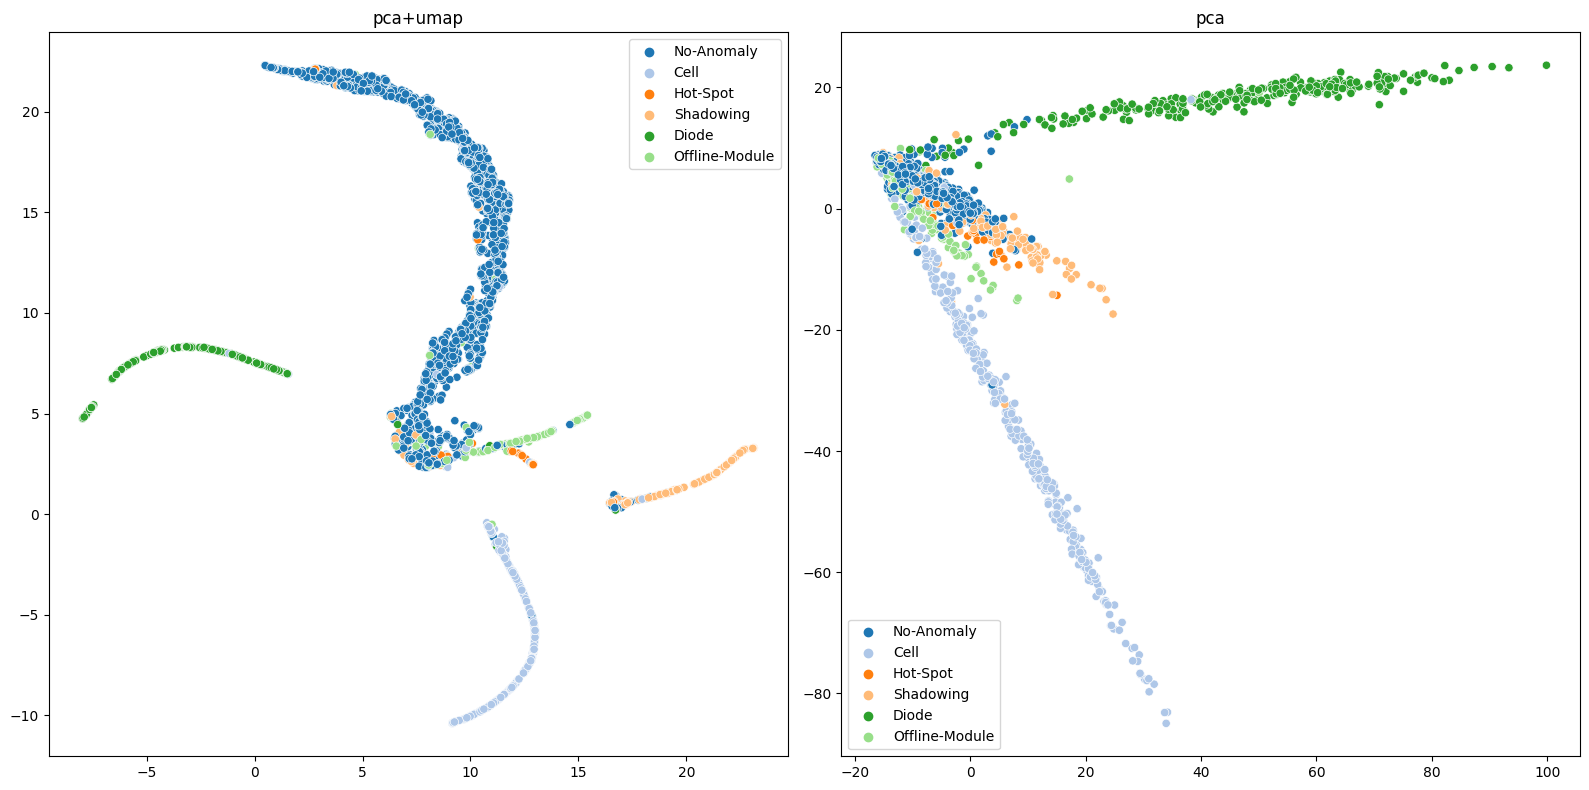

In [26]:
visualize_latent_dim(encoder_model,x_test,y_test.to_numpy(),test_transforms,class_keys)

In [27]:
# visualize_latent_dim(encoder_model,x_train,y_train.to_numpy(),test_transforms)

In [28]:
torch.save(encoder_model.state_dict(),"resnet_98_92.pth")
download_file("/kaggle/working/resnet_98_92.pth","resnet_98_92")

/kaggle/working/resnet_98_92.zip

In [29]:
counts=df["class"].value_counts().values
inv_counts=1/counts
ce_weights=torch.from_numpy((inv_counts)/inv_counts.sum()).to(torch.float32) 

ce_weights

tensor([0.0134, 0.0713, 0.0893, 0.1267, 0.1618, 0.5375])

# Classifier Trainings

In [31]:
percentage=0.7
x_train,y_train=fix_imbalaned_dataset(percentage,X_train,Y_train)

batch_size=128
train_ds=SolarImgDataset(x_train,y_train.to_numpy(),train_transforms)
train_sampler=WeightedRandomSampler(
    weights=torch.DoubleTensor(sampler_weights),
    num_samples=len(sampler_weights),   
    replacement=True                  
)
train_dl=DataLoader(
    train_ds,
    batch_size=batch_size,
    num_workers=4,
    pin_memory=True,
    # shuffle=True,
    sampler=train_sampler
)

test_ds=SolarImgDataset(x_test,y_test.to_numpy(),test_transforms)
test_dl=DataLoader(
    test_ds,
    batch_size=batch_size,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

classifier_model=Classifier(encoder=encoder_model,input_dim=1000,latent_dim=512,train_encoder=False,class_count=class_count)

optimizer = torch.optim.AdamW(classifier_model.classifier.parameters(), lr=0.00001,weight_decay=0.01)#
loss_fn = nn.CrossEntropyLoss()
# loss_fn = FocalCrossEntropy(weights=ce_weights)
classifier_model = trainer(
    classifier_model,
    train_dl,
    test_dl,
    optimizer,
    loss_fn,
    num_epochs=10,
    stop_at_acc=1,
    with_acc=True
)  

Counter({0: 8000, 4: 5600, 1: 5600, 3: 5600, 2: 5600, 5: 5600})
Counter({0: 2000, 1: 376, 4: 300, 3: 211, 5: 165, 2: 50})


  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/97 [00:00<?, ?it/s]

Epoch 01 — loss: 0.3830 — acc: 82.5488%
loss: 0.6581, acc: 92.7789%


  0%|          | 0/97 [00:00<?, ?it/s]

...

Epoch 08 — loss: 0.0211 — acc: 98.8232%
loss: 0.2797, acc: 93.2624%


  0%|          | 0/97 [00:00<?, ?it/s]

Epoch 09 — loss: 0.0222 — acc: 98.7345%
loss: 0.2752, acc: 93.6170%


  0%|          | 0/97 [00:00<?, ?it/s]

Epoch 10 — loss: 0.0206 — acc: 98.7425%
loss: 0.2751, acc: 93.5848%
best Ecpoch :5 - best Loss :0.2712550439195123


In [32]:
torch.save(classifier_model.state_dict(),"classifier_98_92.pth")
download_file("/kaggle/working/classifier_98_92.pth","classifier_98_92")

/kaggle/working/classifier_98_92.zip

  0%|          | 0/25 [00:00<?, ?it/s]

                precision    recall  f1-score   support

    No-Anomaly       0.95      0.97      0.96      2000
          Cell       0.95      0.93      0.94       376
      Hot-Spot       0.87      0.68      0.76        50
     Shadowing       0.84      0.88      0.86       211
         Diode       0.98      0.94      0.96       300
Offline-Module       0.77      0.72      0.75       165

      accuracy                           0.94      3102
     macro avg       0.89      0.85      0.87      3102
  weighted avg       0.94      0.94      0.94      3102



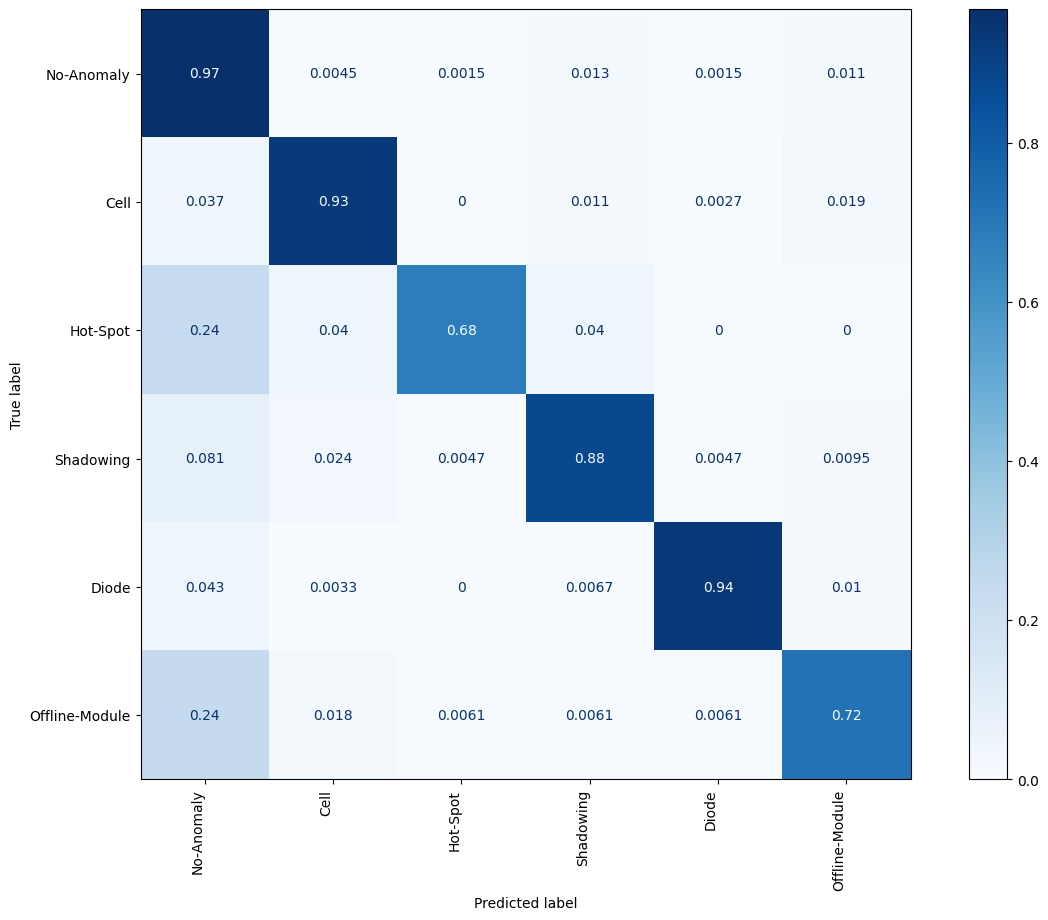

In [34]:
fig,ax=plt.subplots(1,1,figsize=(15,10))
preds_list=[]
true_list=[]
with torch.no_grad():
    for imgs,labels in tqdm(test_dl):
        imgs, labels = imgs.to("cuda"), labels.to("cuda")
        pred=predict(classifier_model,imgs)
        true_labels=labels.tolist()
        preds_list+=pred
        true_list+=true_labels
    report=classification_report(true_list, preds_list,target_names=class_keys)
    print(report)
cm=confusion_matrix(true_list,preds_list)
with np.errstate(divide='ignore', invalid='ignore'):
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    cm_norm = np.nan_to_num(cm_norm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm,
                              display_labels=class_keys)
disp.plot(ax=ax, cmap=plt.cm.Blues)
_=ax.set_xticklabels(class_keys, rotation=90, ha='right')


# Show Dataset

tensor([-0.2000, -0.4605, -0.7853, -0.7080, -0.5270, -0.6167, -1.0018,  0.1217]) tensor([0.3904, 0.8886, 0.0715, 0.6041, 1.0315, 0.0444, 0.3009, 0.6684])
tensor(-0.1583)
tensor([-0.1339, -0.4642, -0.7937, -0.5579, -0.3330, -0.6193, -1.0065,  0.1421]) tensor([0.3093, 0.9012, 0.0744, 0.2423, 0.6572, 0.0872, 0.3146, 0.6759])
tensor(-0.1558)


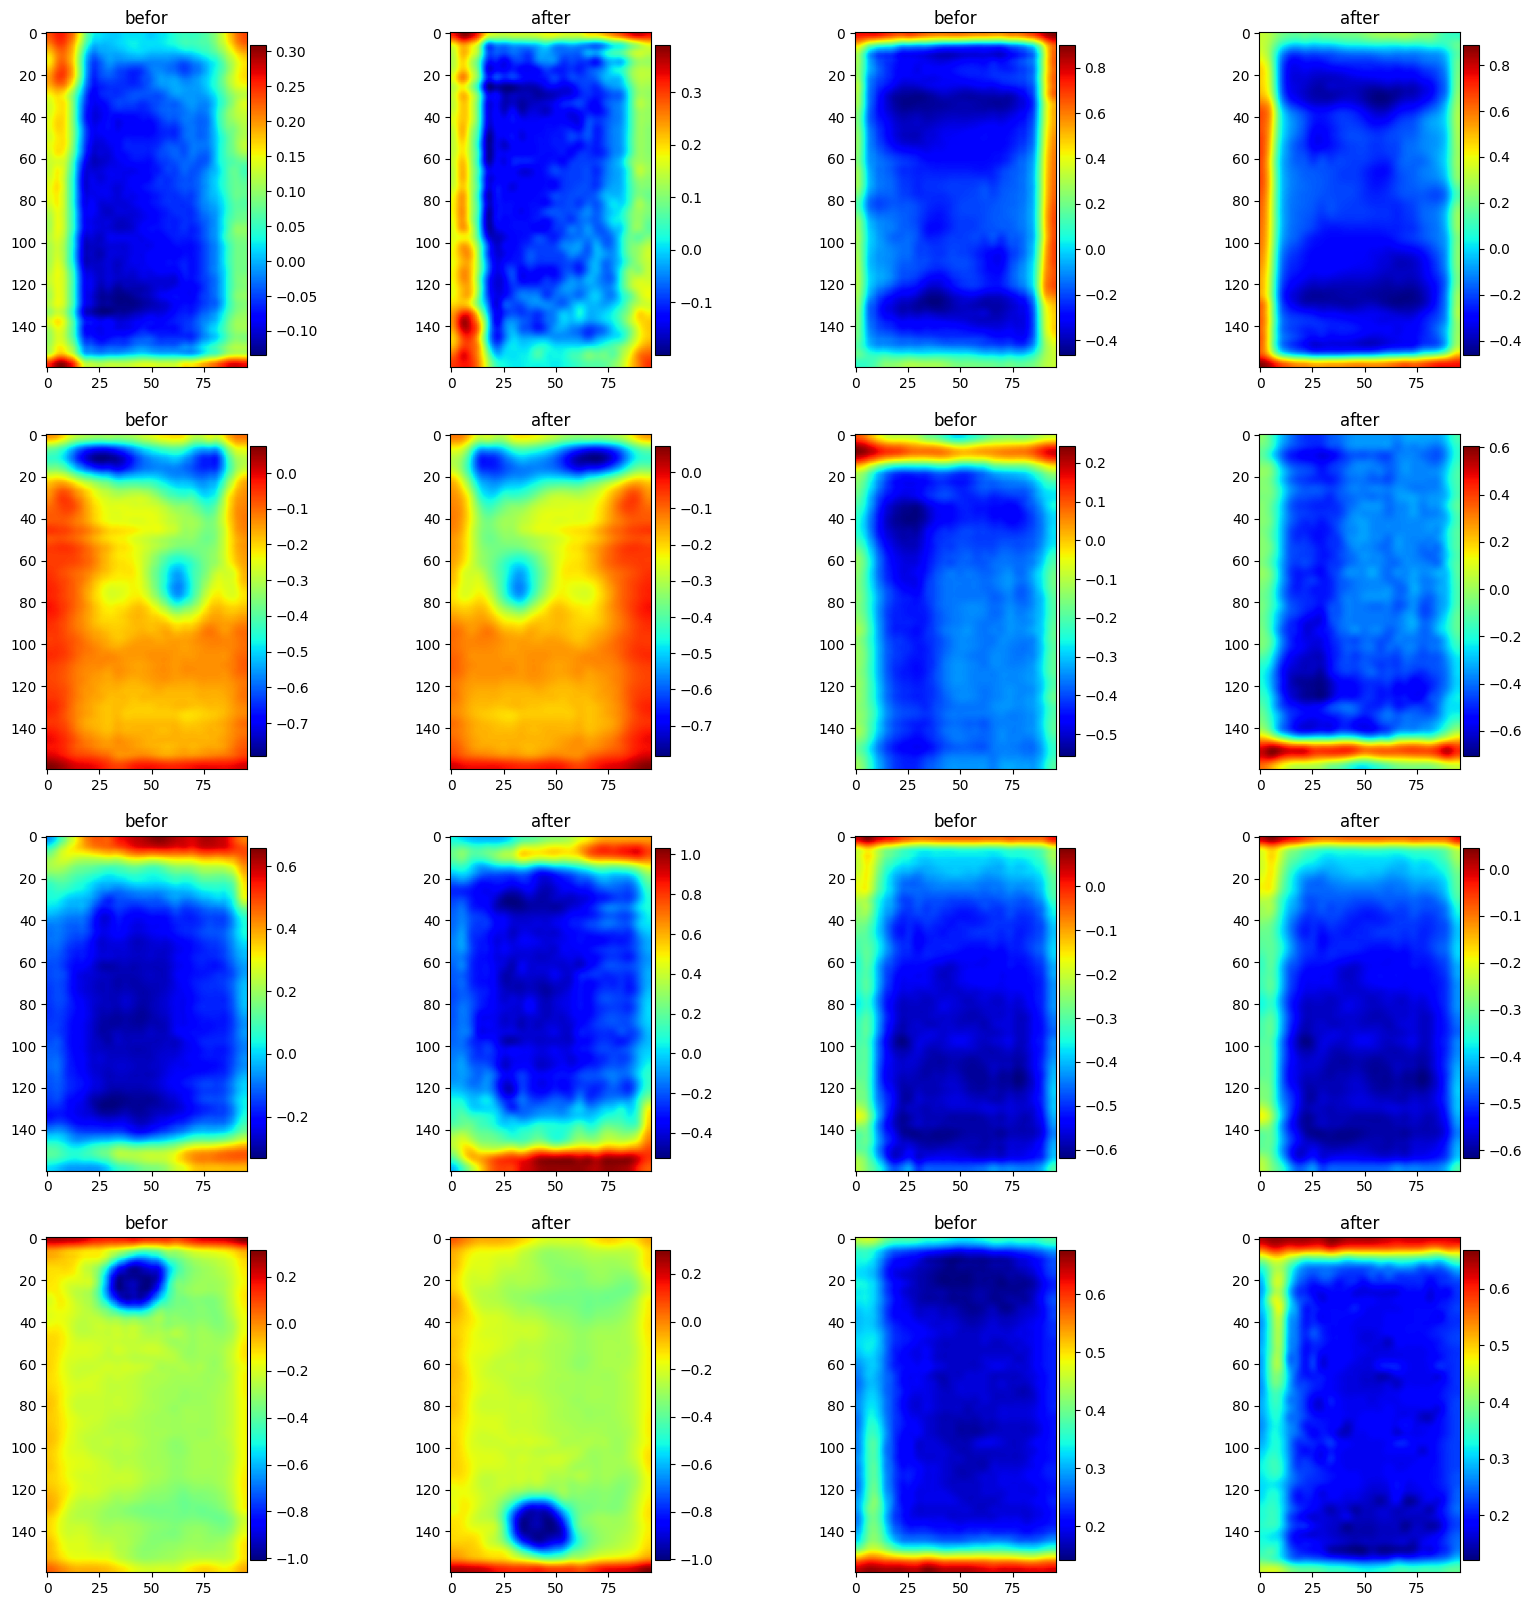

In [39]:
x_train=X_train
y_train=Y_train
resize_shape=(40,24)
draw_train_transforms=T.Compose([
            T.ToPILImage(),
            # T.Resize(resize_shape),
            # T.RandomRotation(degrees=15),

            T.RandomApply([RandomContrast(lower=0.2, upper=2)], p=0.5),
            T.RandomAdjustSharpness(sharpness_factor=3, p=0.5),
            # T.RandomRotation(degrees=5),
            T.RandomHorizontalFlip(0.5),
            T.RandomVerticalFlip(0.5),
            # T.RandomAdjustSharpness(sharpness_factor=3, p=1),
            T.ToTensor(),
            T.Lambda(lambda x: F.interpolate(
                x.unsqueeze(0),                 # -> (1,1,24,40)
                scale_factor=4,
                mode='bicubic',
                align_corners=False
            ).squeeze(0)), 
            T.Lambda(lambda x: KF.gaussian_blur2d(
                x.unsqueeze(0),
                kernel_size=(5,5),
                sigma=(1.0,1.0)
            ).squeeze(0)),

            # AddGaussianNoise(std=0.001),
            # T.RandomErasing(p=0.5, scale=(0.02, 0.1)),
            T.Normalize(mean=[0.5,0.5,0.5],std=[0.5,0.5,0.5])
        ])
draw_test_transforms=T.Compose([
            T.ToPILImage(),
            # T.Resize(resize_shape),
            T.ToTensor(),
            T.Lambda(lambda x: F.interpolate(
                x.unsqueeze(0),                 # -> (1,1,24,40)
                scale_factor=4,
                mode='bicubic',
                align_corners=False
            ).squeeze(0)),
            T.Normalize(mean=[0.5,0.5,0.5],std=[0.5,0.5,0.5])
        ])
draw_ds=DrawImgDataset(x_test,y_train.to_numpy(),draw_train_transforms,draw_test_transforms)
draw_loader=DataLoader(draw_ds,batch_size=8,shuffle=False,pin_memory=True)

    
def show_dataloader(draw_loader,ch,dims=(5,5)):
    fig,axes=plt.subplots(*dims,figsize=(5*dims[1],5*dims[0]))
    axes=axes.reshape(-1)
    
    train_imgs,test_imgs,labels =next(iter(draw_loader))
    if(ch==1):
        print(train_imgs.shape)
        train_imgs=train_imgs.squeeze(1)
    else:
        train_imgs=train_imgs.permute(0,2,3,1).mean(3)
    print(train_imgs.amin(dim=(1, 2)),train_imgs.amax(dim=(1, 2)))
    print(train_imgs.mean())
    train_imgs=train_imgs.numpy()
    if(ch==1):
        test_imgs=test_imgs.squeeze(1)
    else:
        test_imgs=test_imgs.permute(0,2,3,1).mean(3)
    print(test_imgs.amin(dim=(1, 2)),test_imgs.amax(dim=(1, 2)))
    print(test_imgs.mean())
    test_imgs=test_imgs.numpy()
    
    labels=labels.numpy()
    befor_labels=["befor"]*test_imgs.shape[0]
    after_labels=["after"]*train_imgs.shape[0]
    
    draw(axes,test_imgs,0,befor_labels,with_path=False,steps=2,cmap="jet")
    draw(axes,train_imgs,1,after_labels,with_path=False,steps=2,cmap="jet")
    
show_dataloader(draw_loader,dims=(4,4),ch=ch)